##imports :

In [2]:
import pandas as pd
import numpy as np
import re
import json
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.kernel_approximation import Nystroem
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


##Read dataset :

In [3]:
DATA_PATH = '/content/drive/MyDrive/clustring_data'
bank_data = pd.read_csv(f'{DATA_PATH}/bank-full.csv', sep=';')

if bank_data.shape[1] == 1:
    bank_data = pd.read_csv(f'{DATA_PATH}/bank-full.csv', sep=',')

print('shape:', bank_data.shape)
print('columns:', bank_data.columns.tolist())


shape: (41188, 21)
columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'subscribed']


In [4]:
bank_data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


#Exploratory Data Analysis

In [5]:
print("Duplicates in insurance:", bank_data.duplicated().sum())


Duplicates in insurance: 12


In [6]:
duplicates = bank_data[bank_data.duplicated(keep=False)]
print("Duplicate rows:")
print(duplicates.sort_values(by=list(bank_data.columns)))


Duplicate rows:
       age          job   marital            education  default housing loan  \
28476   24     services    single          high.school       no     yes   no   
28477   24     services    single          high.school       no     yes   no   
14155   27   technician    single  professional.course       no      no   no   
14234   27   technician    single  professional.course       no      no   no   
18464   32   technician    single  professional.course       no     yes   no   
18465   32   technician    single  professional.course       no     yes   no   
32505   35       admin.   married    university.degree       no     yes   no   
32516   35       admin.   married    university.degree       no     yes   no   
12260   36      retired   married              unknown       no      no   no   
12261   36      retired   married              unknown       no      no   no   
25183   39       admin.   married    university.degree       no      no   no   
25217   39       admin. 

In [7]:
bank_data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [8]:
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## "unknown"

In [9]:
cat_cols_check = bank_data.select_dtypes(include='object').columns
for c in cat_cols_check:
    n_unknown = (bank_data[c] == 'unknown').sum()
    if n_unknown > 0:
        print(f"{c}: {n_unknown} 'unknown' ({n_unknown/len(bank_data)*100:.1f}%)")


job: 330 'unknown' (0.8%)
marital: 80 'unknown' (0.2%)
education: 1731 'unknown' (4.2%)
default: 8597 'unknown' (20.9%)
housing: 990 'unknown' (2.4%)
loan: 990 'unknown' (2.4%)


## Outliers

In [10]:
numeric_outlier_cols = ['age', 'duration', 'campaign', 'previous']

def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

outlier_summary = []
for c in numeric_outlier_cols:
    lo, hi = iqr_bounds(bank_data[c])
    n_out = ((bank_data[c] < lo) | (bank_data[c] > hi)).sum()
    outlier_summary.append({'column': c, 'lower_bound': lo, 'upper_bound': hi,
                             'n_outliers': n_out, 'pct_outliers': round(n_out/len(bank_data)*100, 2)})

outlier_summary_df = pd.DataFrame(outlier_summary)
display(outlier_summary_df)


,column,lower_bound,upper_bound,n_outliers,pct_outliers
0,age,9.5,69.5,469,1.14
1,duration,-223.5,644.5,2963,7.19
2,campaign,-2.0,6.0,2406,5.84
3,previous,0.0,0.0,5625,13.66


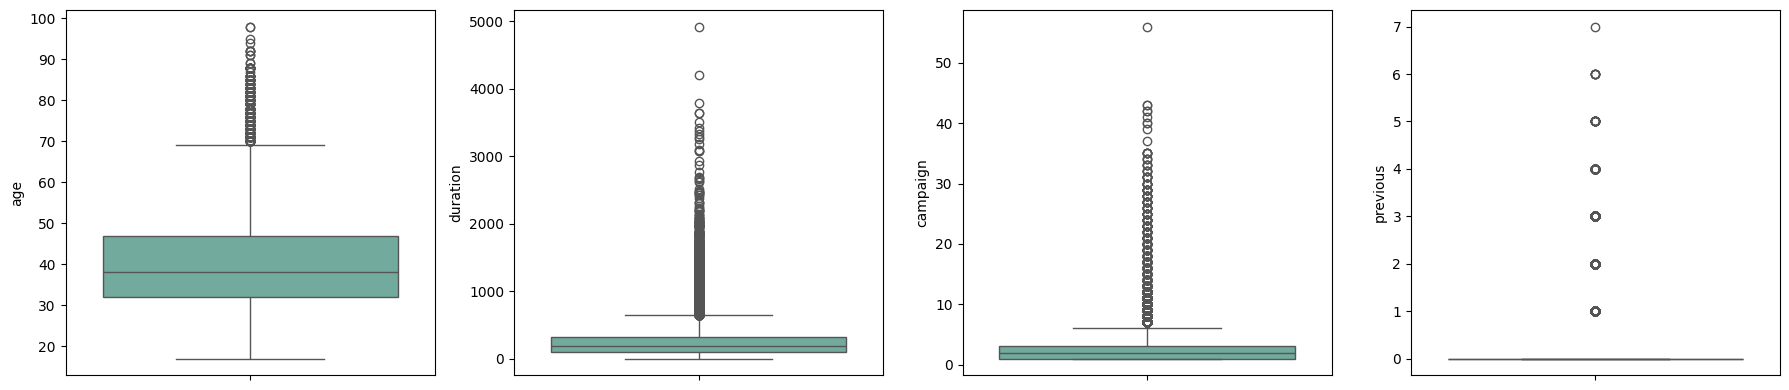

In [11]:
fig, axes = plt.subplots(1, len(numeric_outlier_cols), figsize=(18, 4))
for ax, c in zip(axes, numeric_outlier_cols):
    sns.boxplot(y=bank_data[c], ax=ax, color='#69b3a2')
plt.tight_layout()
plt.show()


# Data Cleaning — التنظيف
1. حذف التكرارات (duplicates)
2. معالجة الـ outliers (capping/winsorizing بطريقة IQR) للأعمدة: `duration`, `campaign`, `previous`
3. تحديد عمر واقعي أقصى (clip) لعمود `age`
4. القيم `"unknown"` منخليها كفئة قائمة بذاتها (منعالجها لاحقاً بالـ Encoding) لأنها ممكن تحمل معنى بحد ذاتها

In [12]:
df = bank_data.copy()

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)


In [13]:
df['age'] = df['age'].clip(lower=17, upper=100)

capped_cols = ['duration', 'campaign', 'previous']
capping_bounds = {}
for c in capped_cols:
    lo, hi = iqr_bounds(df[c])
    capping_bounds[c] = (lo, hi)
    df[c] = df[c].clip(lower=lo, upper=hi)

print("(capping bounds):")
for c, (lo, hi) in capping_bounds.items():
    print(f"  {c}: [{lo:.1f}, {hi:.1f}]")


(capping bounds):
  duration: [-223.5, 644.5]
  campaign: [-2.0, 6.0]
  previous: [0.0, 0.0]


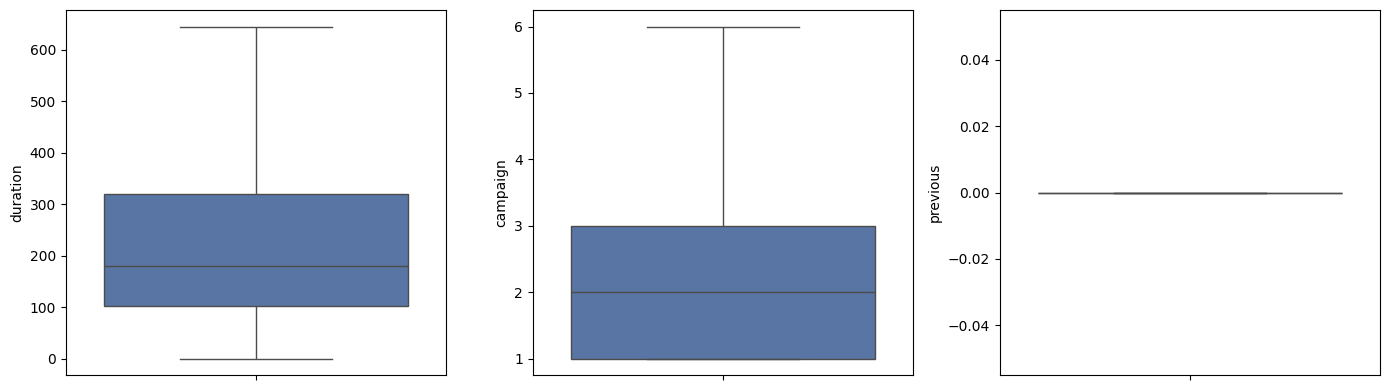

In [14]:
fig, axes = plt.subplots(1, len(capped_cols), figsize=(14, 4))
for ax, c in zip(axes, capped_cols):
    sns.boxplot(y=df[c], ax=ax, color='#4c72b0')
plt.tight_layout()
plt.show()


# Feature Extraction — life_stage

In [15]:
def life_stage(age):
    if age < 25:
        return 'young_adult'
    elif age < 40:
        return 'adult'
    elif age < 60:
        return 'middle_aged'
    else:
        return 'senior'

df['life_stage'] = df['age'].apply(life_stage)
df['life_stage'].value_counts()


,count
life_stage,
adult,21533
middle_aged,17384
senior,1192
young_adult,1067


# Feature Extraction

In [16]:
season_map = {
    'dec':'winter','jan':'winter','feb':'winter',
    'mar':'spring','apr':'spring','may':'spring',
    'jun':'summer','jul':'summer','aug':'summer',
    'sep':'autumn','oct':'autumn','nov':'autumn'
}
df['season'] = df['month'].map(season_map)

PDAYS_NONE = 999
df['was_contacted_before'] = (df['pdays'] != PDAYS_NONE).astype(int)
df['pdays_clean'] = df['pdays'].replace(PDAYS_NONE, np.nan)

df['total_contacts'] = df['campaign'] + df['previous']
df['prior_success'] = (df['poutcome'] == 'success').astype(int)
df['engagement_rate'] = df['duration'] / df['campaign']


df_features = df.drop(columns=['subscribed', 'pdays', 'month'])

print(df_features.shape)
df_features.head()


(41176, 25)


,age,job,marital,education,default,housing,loan,contact,day_of_week,duration,...,cons.conf.idx,euribor3m,nr.employed,life_stage,season,was_contacted_before,pdays_clean,total_contacts,prior_success,engagement_rate
0,56,housemaid,married,basic.4y,no,no,no,telephone,mon,261.0,...,-36.4,4.857,5191.0,middle_aged,spring,0,NaN,1,0,261.0
1,57,services,married,high.school,unknown,no,no,telephone,mon,149.0,...,-36.4,4.857,5191.0,middle_aged,spring,0,NaN,1,0,149.0
2,37,services,married,high.school,no,yes,no,telephone,mon,226.0,...,-36.4,4.857,5191.0,adult,spring,0,NaN,1,0,226.0
3,40,admin.,married,basic.6y,no,no,no,telephone,mon,151.0,...,-36.4,4.857,5191.0,middle_aged,spring,0,NaN,1,0,151.0
4,56,services,married,high.school,no,no,yes,telephone,mon,307.0,...,-36.4,4.857,5191.0,middle_aged,spring,0,NaN,1,0,307.0


# Feature Engineering


In [17]:
numeric_cols = ['age', 'duration', 'campaign', 'previous', 'pdays_clean',
                 'total_contacts', 'engagement_rate',
                 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
ordinal_cols = ['education']
education_order = [['unknown', 'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                     'high.school', 'professional.course', 'university.degree']]
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan', 'contact',
                'day_of_week', 'poutcome', 'life_stage', 'season']
passthrough_cols = ['was_contacted_before', 'prior_success']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])

ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(categories=education_order)),
])

nominal_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('ord', ordinal_pipeline, ordinal_cols),
    ('nom', nominal_pipeline, nominal_cols),
    ('pass', 'passthrough', passthrough_cols),
])

feature_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('select', VarianceThreshold(threshold=0.001)),
])

X_processed = feature_pipeline.fit_transform(df_features)
X_processed = X_processed.toarray() if hasattr(X_processed, 'toarray') else X_processed


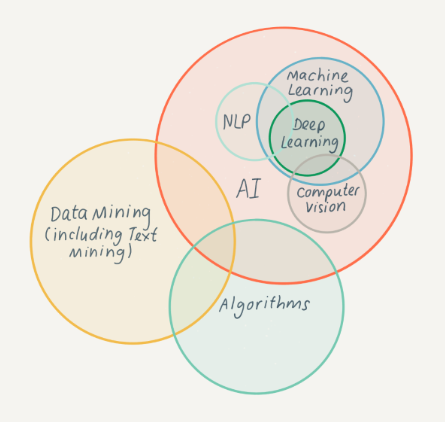